In [1]:
print("My ML journey begins here! 🚀")

My ML journey begins here! 🚀


In [6]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Display plots inside the notebook
%matplotlib inline

print("Libraries imported successfully!")

Libraries imported successfully!


In [7]:
# Create dataset
data = {
    "StudyHours": [2, 3, 4, 5, 6, 7, 8, 1, 9, 5],
    "Attendance": [60, 65, 70, 75, 80, 85, 90, 55, 95, 78],
    "PreviousMarks": [50, 55, 60, 65, 70, 75, 85, 45, 92, 68],
    "FinalMarks": [52, 57, 63, 68, 72, 78, 88, 48, 95, 74]
}

df = pd.DataFrame(data)

# Display dataset
df

,StudyHours,Attendance,PreviousMarks,FinalMarks
0,2,60,50,52
1,3,65,55,57
2,4,70,60,63
3,5,75,65,68
4,6,80,70,72
5,7,85,75,78
6,8,90,85,88
7,1,55,45,48
8,9,95,92,95
9,5,78,68,74


In [8]:
df.to_csv("student_data.csv", index=False)
print("Dataset saved successfully!")

Dataset saved successfully!


In [9]:
# Display first five rows
df.head()

# Dataset information
df.info()

# Statistical summary
df.describe()

# Check for missing values
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   StudyHours     10 non-null     int64
 1   Attendance     10 non-null     int64
 2   PreviousMarks  10 non-null     int64
 3   FinalMarks     10 non-null     int64
dtypes: int64(4)
memory usage: 452.0 bytes


StudyHours       0
Attendance       0
PreviousMarks    0
FinalMarks       0
dtype: int64

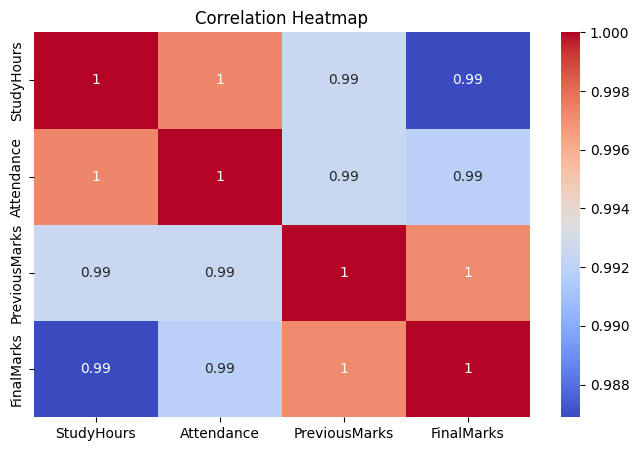

In [10]:
plt.figure(figsize=(8, 5))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

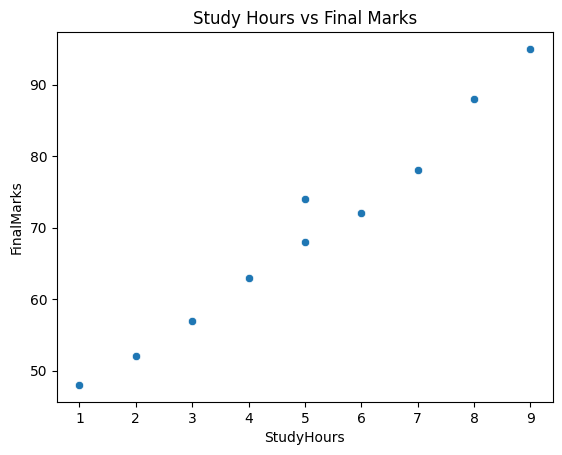

In [11]:
sns.scatterplot(x="StudyHours", y="FinalMarks", data=df)
plt.title("Study Hours vs Final Marks")
plt.show()

In [12]:
#TRAINING
# Define features and target variable
X = df[["StudyHours", "Attendance", "PreviousMarks"]]
y = df["FinalMarks"]

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [13]:
#EVALUATION
# Make predictions
y_pred = model.predict(X_test)

# Evaluate performance
print("R² Score:", r2_score(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))

R² Score: 0.9993886623974978
Mean Absolute Error: 0.3894409937888028


In [14]:
#Predict a New Student’s Performance
# Predict performance for a new student
new_student = pd.DataFrame({
    "StudyHours": [6],
    "Attendance": [85],
    "PreviousMarks": [70]
})

predicted_marks = model.predict(new_student)[0]
print(f"Predicted Final Marks: {predicted_marks:.2f}")

Predicted Final Marks: 77.94


In [15]:
#Classify Performance Level
def classify_performance(score):
    if score >= 80:
        return "Excellent 🌟"
    elif score >= 50:
        return "Average 👍"
    else:
        return "Needs Improvement 📘"--

category = classify_performance(predicted_marks)
print("Performance Category:", category)

Performance Category: Average 👍


In [16]:
#Save the Trained Model
import pickle

# Save the model
with open("student_performance_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


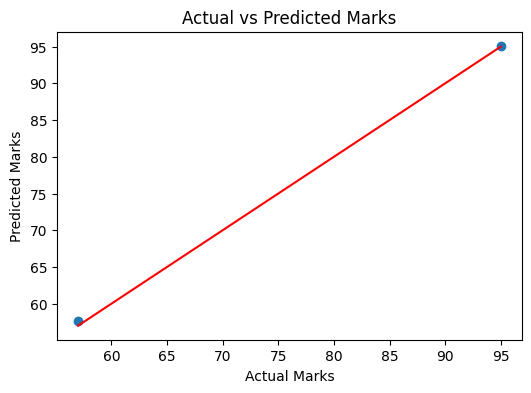

In [17]:
#Visualize Actual vs Predicted Values
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred)
plt.plot(y_test, y_test, color='red')
plt.xlabel("Actual Marks")
plt.ylabel("Predicted Marks")
plt.title("Actual vs Predicted Marks")
plt.show()

In [21]:
import streamlit as st
import numpy as np
import pickle

# Load the trained model
with open("student_performance_model.pkl", "rb") as file:
    model = pickle.load(file)

# Page configuration
st.set_page_config(page_title="Student Performance Predictor", page_icon="🎓")

# Title and description
st.title("🎓 Student Performance Predictor")
st.markdown("Predict a student's final marks using Machine Learning.")

st.divider()

# User Inputs
st.subheader("📊 Enter Student Details")

study_hours = st.slider("📘 Study Hours", 0.0, 12.0, 5.0, step=0.5)
attendance = st.slider("📅 Attendance (%)", 0, 100, 75)
previous_marks = st.slider("📝 Previous Marks", 0, 100, 60)

st.divider()

# Prediction Function
def classify_performance(score):
    if score >= 80:
        return "Excellent 🌟"
    elif score >= 50:
        return "Average 👍"
    else:
        return "Needs Improvement 📘"

# Predict Button
if st.button("🔮 Predict Performance"):
    input_data = np.array([[study_hours, attendance, previous_marks]])
    prediction = model.predict(input_data)[0]
    category = classify_performance(prediction)

    st.subheader("📢 Prediction Result")
    st.success(f"🎯 Predicted Final Marks: **{prediction:.2f}**")
    st.info(f"🏆 Performance Category: **{category}**")

# Footer
st.markdown("---")
st.markdown("Developed by **Adi** | BTech CSE In-House Training Project")

2026-04-14 14:53:01.727 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 14:53:01.733 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 14:53:01.733 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 14:53:01.733 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 14:53:01.735 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 14:53:01.736 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 14:53:01.736 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-14 14:53:01.738 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [20]:
import pickle

with open("student_performance_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!
